In [2]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df():
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column == 'name':
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

In [3]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [6]:
args = ['dataset', 'model_name', 'answerable_only']


runs = {
    'rtkaljty': 'squad-all_answerable',
    'n5pln8v3': 'squad-w_unanswerable'
}

all_results, configs = {}, {}
for wandbid in runs:
    run = api.run(f'goatml/semantic_uncertainty/{wandbid}')
    configs[wandbid] = run.config
    all_results[wandbid], _ = restore_file(wandbid)

configs.keys()

dict_keys(['rtkaljty', 'n5pln8v3'])

In [7]:
DeepDiff(configs['rtkaljty'], configs['n5pln8v3'])

{'dictionary_item_added': [root['compute_accuracy_at_all_temps']],
 'values_changed': {"root['experiment_lot']": {'new_value': 'Unnamed Experiment',
   'old_value': 'run_25_nov'},
  "root['answerable_only']": {'new_value': False, 'old_value': True}}}

In [11]:
arg_df, uniq_name, unique_cols = get_arg_df()
arg_df

,wandbid,c.dataset,c.model_name,c.answerable_only,UNIQ-c.answerable_only
0,rtkaljty,squad,Llama-2-70b-chat,True,True
1,n5pln8v3,squad,Llama-2-70b-chat,False,False


model,squad
dataset,
all_answerable,0.3225
w_unanswerable,0.1525


Text(0, 0.5, 'accuracy')

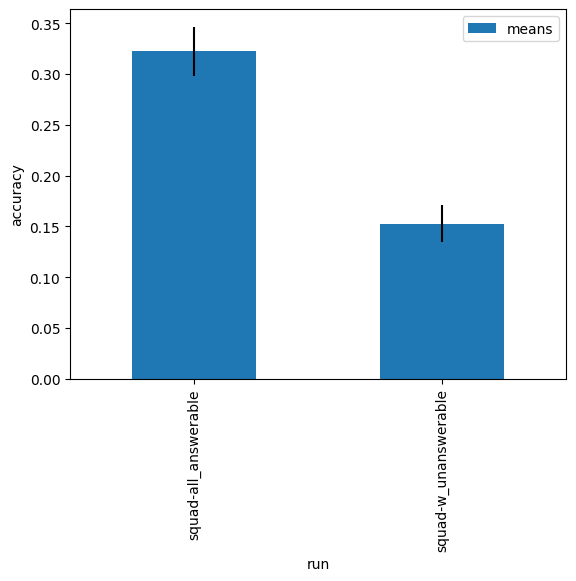

In [12]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

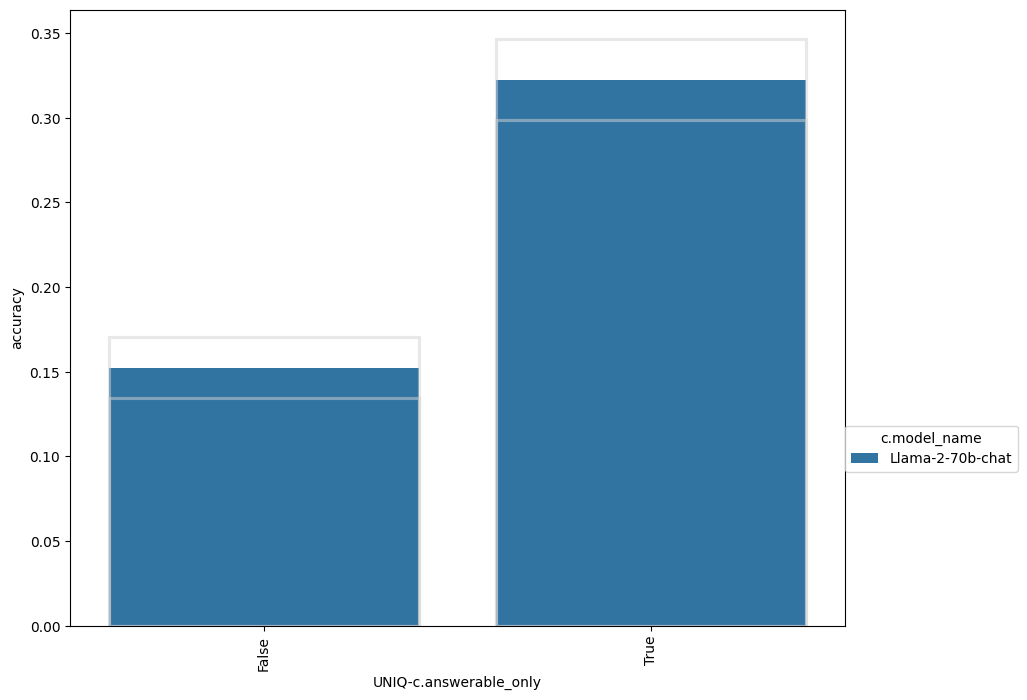

In [15]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc[acc], metric='means', x=uniq_name, hue='c.model_name')
plt.gca().set_ylabel(acc)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


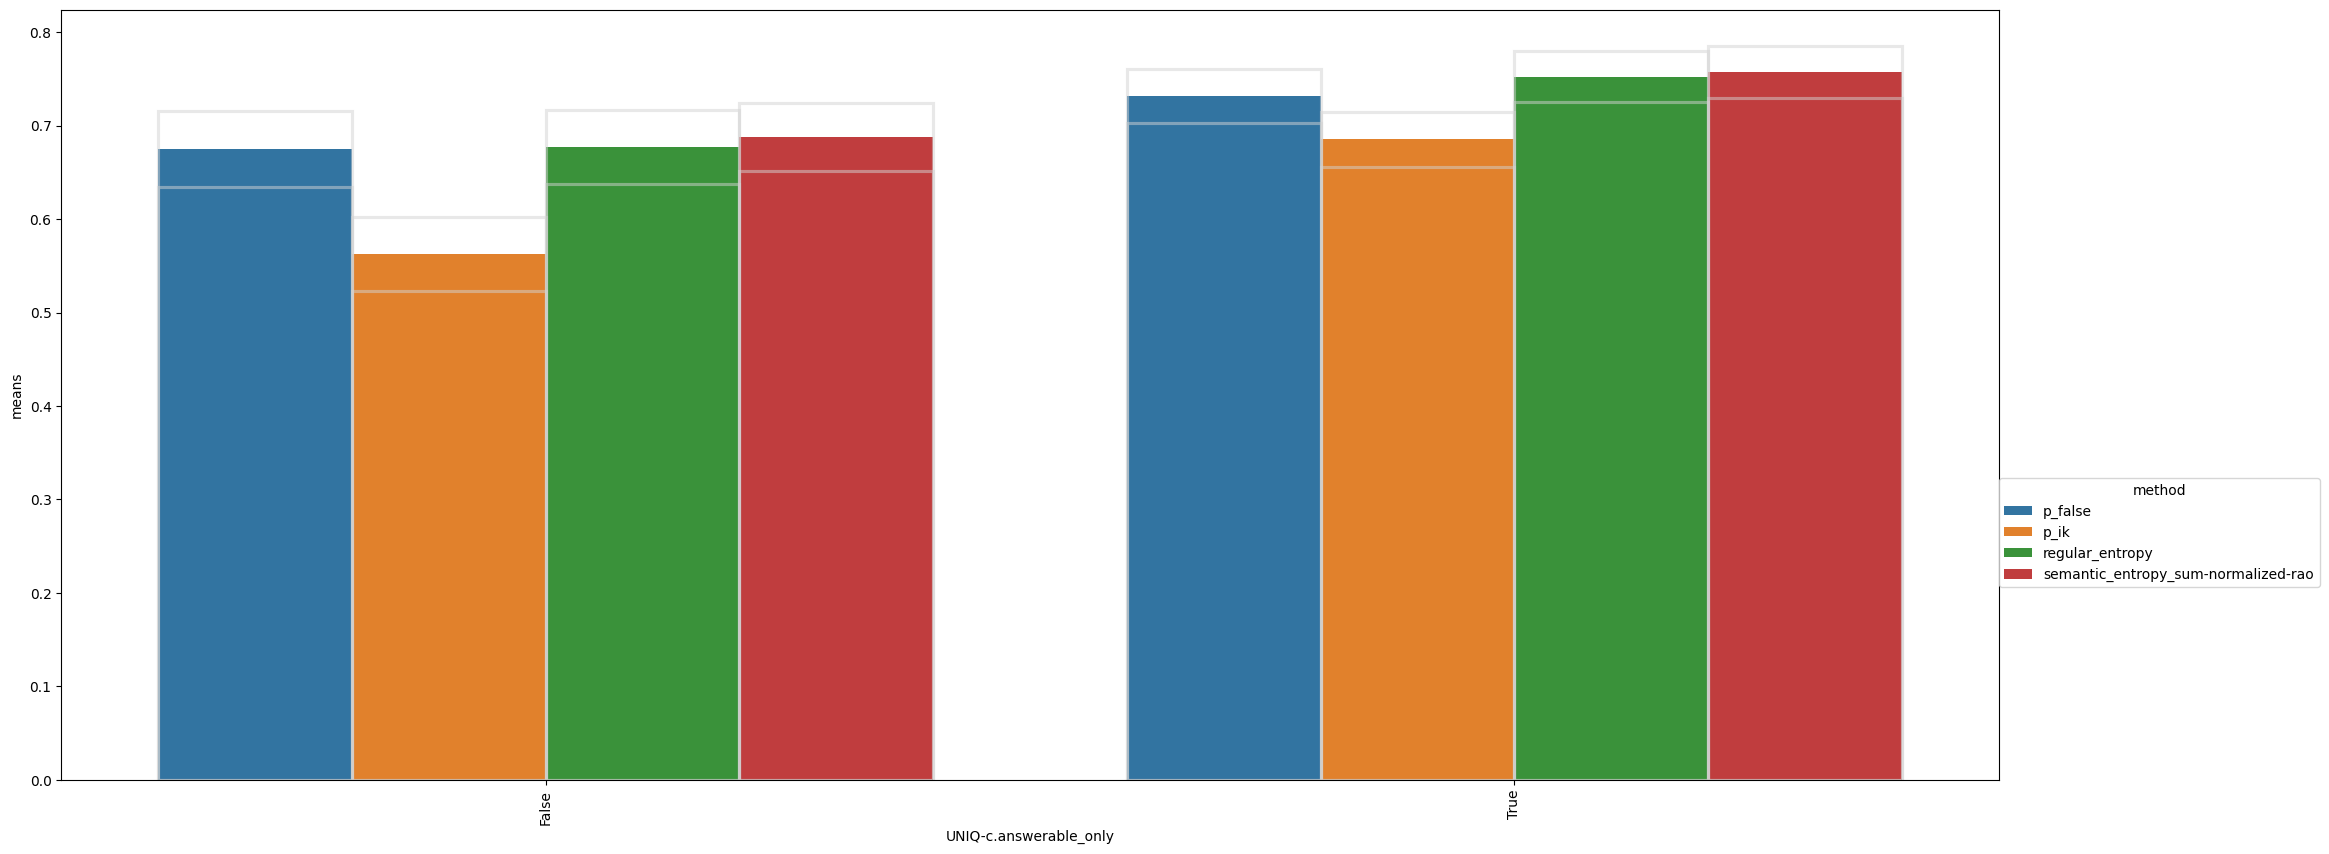

In [20]:

# main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']
main_methods = ['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']


plot_grouped(
    all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)